<a href="https://colab.research.google.com/github/rxphaelbihag/DS171-Intro-to-Supervised-Machine-Learning/blob/main/Intro_to_Supervised_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Laboratory Activity 1: Intro to Supervised Machine Learning
Student Number: 2024-05203

Section: N-1L

## I. Study Questions

#### 1. Write out the formal mathematical definition of a training set $D$ and design matrix $X$ for a credit dataset containing 1000 applicants and 20 attributes.

**Answer:**

The training set $D$ is defined as:

$$D = \{(\textbf{x}_1, y_1), (\textbf{x}_2, y_2), \dots, (\textbf{x}_n, y_n) \}$$

where:
$$
\begin{align*}
    &\textbf{x}_{i}\in \mathbb{R}^{20} \\
    y_i &= \text{the target variable} \\
    n&=1000 \\
\end{align*}
$$


The design matrix $X$ is defined as:

$$X =
\begin{pmatrix}
    x_{1,1} & x_{1,2} & \dots & x_{1,20} \\
    x_{2,1} & x_{2,2} & \dots & x_{2,20} \\
    \vdots & \vdots & \ddots & \vdots \\
    x_{1000,1} & x_{1000,2} & \dots & x_{1000,20} \\
\end{pmatrix}$$



#### 2. Differentiate between Discriminative and Generative models in terms of probabilistic modeling. Which category does a Decision Tree belong to?

**Answer:**
Discriminative models learn the conditional probability while Generative models learn the joing probability. The Decision tree belongs to the discriminative category.

## II. Experimental Data and Bias-Variance Analysis



### 1. Model Capacity Evaluation

#### Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

#### Load the dataset

In [ ]:
# Loading the dataset
german = fetch_openml(data_id=31, as_frame=True, parser='pandas')
df = german.frame

In [ ]:
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6,critical/other existing credit,radio/tv,1169,no known savings,>=7,4,male single,none,...,real estate,67,none,own,2,skilled,1,yes,yes,good
1,0<=X<200,48,existing paid,radio/tv,5951,<100,1<=X<4,2,female div/dep/mar,none,...,real estate,22,none,own,1,skilled,1,none,yes,bad
2,no checking,12,critical/other existing credit,education,2096,<100,4<=X<7,2,male single,none,...,real estate,49,none,own,1,unskilled resident,2,none,yes,good
3,<0,42,existing paid,furniture/equipment,7882,<100,4<=X<7,2,male single,guarantor,...,life insurance,45,none,for free,1,skilled,2,none,yes,good
4,<0,24,delayed previously,new car,4870,<100,1<=X<4,3,male single,none,...,no known property,53,none,for free,2,skilled,2,none,yes,bad


#### Preprocessing the dataset

In [ ]:
# One-hot encode categorical features
X = pd.get_dummies(df.drop(columns=['class']), drop_first=True)
y = df['class']

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.1,
                                                    random_state=42)

#### Model Training and Evaluation

<Axes: xlabel='depth'>

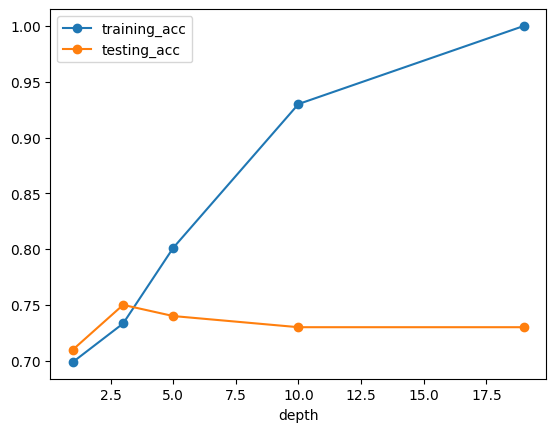

In [ ]:
# define the depths
depth_list = [1,3,5,10, None]

 # dictionary to hold the results
results1 = {
    'depth' : depth_list,
    'training_acc' : [],
    'testing_acc' : []
}

for depth in depth_list:
    # Create Decision Tree classifer object
    clf = DecisionTreeClassifier(max_depth=depth)

    # Train Decision Tree Classifer
    clf = clf.fit(X_train,y_train)

    # Generate predictions
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    # Model Accuracy
    results1['training_acc'].append(metrics.accuracy_score(y_train, y_train_pred))
    results1['testing_acc'].append(metrics.accuracy_score(y_test, y_test_pred))

    # Get the actual depth of the unconstrained
    if depth == None:
        actual_depth = clf.get_depth()
        results1['depth'][4] = actual_depth

results1 = pd.DataFrame(results1)
results1.plot(x='depth', kind='line', marker='o')

In [ ]:
results1

,depth,training_acc,testing_acc
0,1,0.698889,0.71
1,3,0.733333,0.75
2,5,0.801111,0.74
3,10,0.930000,0.73
4,19,1.000000,0.73


#### Model Capacity Evaluation Table

| Capacity | Training Accuracy (%) | Testing Accuracy (%) | Model State |
|---|---|---|---|
| Depth = 1 | 69.88 | 71.00 | Under-fitting |
| Depth = 3 | 73.33 | 75.00 | Appropriate-fitting |
| Depth = 5 | 80.11 | 74.00 | Over-fitting |
| Depth = 10 | 93.00 | 73.00 | Over-fitting |
| Full (Unconstrained) | 100.00 | 73.33 | Over-fitting |

### 2. Numerical Bias-Variance Decomposition

#### Import Additional Libraries

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

#### Constants Initialization

In [ ]:
M = 100             # number of Monte Carlo draws
n = 25              # Samples per dataset
sigma_sq = 0.04     # Irreducible noise variance
x_eval = np.array([[0.5]])
f_eval = np.sin(2 * np.pi * 0.5)    # True target = 0.0

degrees = [1,3,15]
results2 = {
        'degree' : degrees,
        'bias': [],
        'variance': [],
        'mse' : []
    }

#### Model Training and Evaluation

In [ ]:
for degree in degrees:
    predictions = []

    for _ in range(M):

        # Sample synthetic dataset D_m
        X_train = np.random.uniform(0, 1, (n,1))
        y_train = np.sin(2 * np.pi * X_train.ravel()) + np.random.normal(0, np.sqrt(sigma_sq), n)

        # Fit polynomial regression model
        model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
        model.fit(X_train, y_train)

        # Store prediction at x = 0.5
        predictions.append(model.predict(x_eval)[0])

    predictions = np.array(predictions)

    # MSE Calculation
    mean = np.mean(predictions)
    bias_sq = (mean - f_eval) ** 2
    variance = np.var(predictions)
    mse = bias_sq + variance + sigma_sq

    results2['bias'].append(bias_sq)
    results2['variance'].append(variance)
    results2['mse'].append(mse)

results2 = pd.DataFrame(results2)

In [ ]:
results2

,degree,bias,variance,mse
0,1,0.000362,0.007900,0.048262
1,3,0.000002,0.004978,0.044980
2,15,0.000004,0.200363,0.240368


#### Numerical Bias-Variance Decomposition Table

| Model Degree | Emperical Bias^2 | Emperical Variance | MSE |
|---|---|---|---|
| Depth = 1 | 0.000004	 | 0.009345	 | 0.049349 |
| Depth = 3 | 0.000025	 | 0.004111 | 0.044136 |
| Depth = 15 | 0.000001 | 0.092562 | 0.132563 |

#### Describe how emperical bias and variance change as polynomial degree increases from 1 to 15. How does this align with the capacity curve in the figure below?

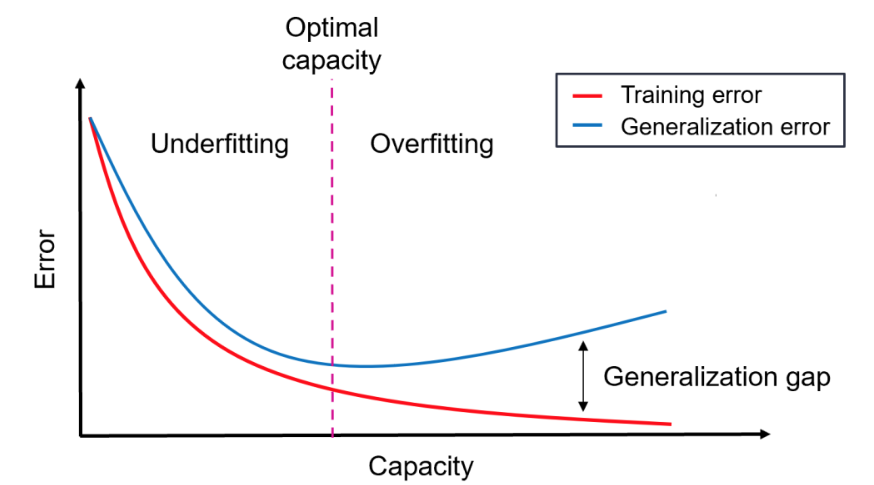

**Answer:**
The bias started low, increased, then decreased dramatically. Inversely, variance started high, decreased slightly, then increased dramatically. This mirrors the curve, reflecting the generalization gap.

## III. Synthesis

#### 1. Connect the no Free Lunch (NFL) theorem and Occam's Razor to your choices of model capacity in this lab. Why shouldn't we always default to complex models?

**Answer:**

The No Free Lunch (NFL) states that no single algorithm, especially optimizations or machine learning models, is considered best for every single task. Moreover, Occam's Razor states that a model with simpler configurations or assumptions is preferred because it is more likely to generalize well to new data. These theorems help guide us in model building in machine learning because it ensures the models are robust and effective. By not defaulting to the much complex models, we avoid overfitting and ensure the models can adapt to unseen data.